<a href="https://colab.research.google.com/github/MMujtabaX/nlpllm/blob/main/NLP_LLM_Complete_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 NLP & LLM Project
**6 Parts and 12 Tasks**

---
**Dataset Used:** Amazon Polarity Reviews (fancyzhx/amazon_polarity — HuggingFace)
**Sample size:** 20,000 reviews (balanced positive / negative)


## ⚙️ Step 0 — Install All Dependencies

In [1]:
# Install all required packages
!pip install -q nltk gensim scikit-learn pandas numpy matplotlib seaborn wordcloud datasets transformers

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
print("✅ All packages installed and NLTK data downloaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 73.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ All packages installed and NLTK data downloaded!


## 📦 Step 0.1 — Load Dataset

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

N_REVIEWS = 20000   # was 500: more data makes Word2Vec and the classifiers meaningful
print(f"Loading {N_REVIEWS:,} reviews...")

# ✅ Uses native Parquet format — no loading script, guaranteed to work
dataset = load_dataset("fancyzhx/amazon_polarity", split="train", streaming=True)

rows = []
for i, row in enumerate(dataset):
    if i >= N_REVIEWS:
        break
    rows.append(row)

df = pd.DataFrame(rows)

# This dataset has 'content' (review text) and 'label' (0=negative, 1=positive)
# We rename to match the rest of the notebook
df = df.rename(columns={'content': 'text'})
df['rating'] = df['label'].map({0: 1, 1: 5})   # map to 1/5 star scale
df = df[['text', 'rating']].dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"✅ Loaded {len(df)} reviews")
print(f"Positive: {(df['rating']==5).sum()}  |  Negative: {(df['rating']==1).sum()}")
print("\nSample Reviews:")
print(df.head(3)[['text','rating']].to_string())

Loading 20,000 reviews...


README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

✅ Loaded 20000 reviews
Positive: 10257  |  Negative: 9743

Sample Reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             text  rating
0                                                                                                                                                                  

---
# 🔵 PART 1 — Text Processing & Normalization

---
## ✅ Task 1 — Raw Text Cleaning

In [3]:
import re

def clean_text(text):
    """Apply lowercasing, remove punctuation, remove numbers."""
    text = text.lower()                         # Lowercasing
    text = re.sub(r'[^\w\s]', '', text)         # Remove punctuation
    text = re.sub(r'\d+', '', text)             # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()    # Normalize whitespace
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# Show comparison
print("=" * 60)
for i in range(3):
    print(f"\n--- Review #{i+1} ---")
    print(f"ORIGINAL : {df['text'][i][:200]}")
    print(f"CLEANED  : {df['cleaned_text'][i][:200]}")
    print("=" * 60)

print("\n📝 JUSTIFICATION for removing numbers:")
print("Numbers like '5/10', '3 stars' don't add semantic value for most NLP tasks.")
print("However, in price-sensitive or rating analysis, numbers CAN be important.")
print("For this exercise, we remove them to focus on linguistic content.")


--- Review #1 ---
ORIGINAL : This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I
CLEANED  : this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross but out of all of the games i ha

--- Review #2 ---
ORIGINAL : I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The 
CLEANED  : im reading a lot of reviews saying that this is the best game soundtrack and i figured that id write a review to disagree a bit this in my opinino is yasunori mitsudas ultimate masterpiece the music i

--- Review #3 ---
ORIGINAL : This soundtrack is my favorite music of all time, hands down. The intense sadness of

## ✅ Task 2 — Tokenization & Stopwords

In [4]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

stop_words = set(stopwords.words('english'))

# Tokenize
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

# Remove stopwords
df['tokens_no_stop'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

# Comparison
sample_idx = 0
print("=" * 60)
print("BEFORE Stopword Removal:")
print(df['tokens'][sample_idx][:20])
print(f"Token count: {len(df['tokens'][sample_idx])}")

print("\nAFTER Stopword Removal:")
print(df['tokens_no_stop'][sample_idx][:20])
print(f"Token count: {len(df['tokens_no_stop'][sample_idx])}")

# Words that MIGHT be wrongly removed
print("\n⚠️  Words in NLTK stoplist that might be important in reviews:")
potentially_important = ['not', 'no', 'nor', 'never', 'very', 'more', 'most', 'won', 'doesn', 'didn', "don't", "isn't", "wasn't"]
wrongly_removed = [w for w in potentially_important if w in stop_words]
print(wrongly_removed)
print("\n🔍 'not', 'no', 'never' are critical for sentiment analysis!")
print("   Example: 'not good' → after stopword removal → 'good' (meaning reversed!)")

# ✅ Sentiment-safe stopword list: keep negations so 'not good' stays 'not good'
NEGATIONS = {'not', 'no', 'nor', 'never', 'very', 'too', 'only', 'against'}
sentiment_stop_words = stop_words - NEGATIONS
df['tokens_keep_neg'] = df['tokens'].apply(lambda tokens: [w for w in tokens if w not in sentiment_stop_words])
print(f"\n✅ Created 'tokens_keep_neg' using a stopword list without: {sorted(NEGATIONS)}")


BEFORE Stopword Removal:
['this', 'sound', 'track', 'was', 'beautiful', 'it', 'paints', 'the', 'senery', 'in', 'your', 'mind', 'so', 'well', 'i', 'would', 'recomend', 'it', 'even', 'to']
Token count: 75

AFTER Stopword Removal:
['sound', 'track', 'beautiful', 'paints', 'senery', 'mind', 'well', 'would', 'recomend', 'even', 'people', 'hate', 'vid', 'game', 'music', 'played', 'game', 'chrono', 'cross', 'games']
Token count: 41

⚠️  Words in NLTK stoplist that might be important in reviews:
['not', 'no', 'nor', 'very', 'more', 'most', 'won', 'doesn', 'didn', "don't", "isn't", "wasn't"]

🔍 'not', 'no', 'never' are critical for sentiment analysis!
   Example: 'not good' → after stopword removal → 'good' (meaning reversed!)

✅ Created 'tokens_keep_neg' using a stopword list without: ['against', 'never', 'no', 'nor', 'not', 'only', 'too', 'very']


## ✅ Task 3 — Stemming vs Lemmatization

In [5]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Apply to a sample
sample_tokens = df['tokens_no_stop'][0][:15]

stemmed    = [stemmer.stem(w) for w in sample_tokens]
lemmatized = [lemmatizer.lemmatize(w) for w in sample_tokens]

# Display comparison table
comparison = pd.DataFrame({
    'Original'   : sample_tokens,
    'Stemmed'    : stemmed,
    'Lemmatized' : lemmatized
})
print(comparison.to_string(index=False))

# Also compare on some illustrative words
print("\n--- Classic Examples ---")
test_words = ['running', 'better', 'studies', 'playing', 'goes', 'corpora', 'wolves']
ex = pd.DataFrame({
    'Word'       : test_words,
    'Stem'       : [stemmer.stem(w) for w in test_words],
    'Lemma'      : [lemmatizer.lemmatize(w) for w in test_words]
})
print(ex.to_string(index=False))

print("""
📌 REFLECTION:
  ┌─────────────────────┬─────────────────────────────────────┐
  │ Use Case            │ Recommended Method                  │
  ├─────────────────────┼─────────────────────────────────────┤
  │ Search Engines      │ Stemming (speed > precision)        │
  │ Chatbots            │ Lemmatization (grammar correctness) │
  │ Text Classification │ Lemmatization (better features)     │
  └─────────────────────┴─────────────────────────────────────┘
""")

 Original  Stemmed Lemmatized
    sound    sound      sound
    track    track      track
beautiful   beauti  beautiful
   paints    paint      paint
   senery   seneri     senery
     mind     mind       mind
     well     well       well
    would    would      would
 recomend recomend   recomend
     even     even       even
   people    peopl     people
     hate     hate       hate
      vid      vid        vid
     game     game       game
    music    music      music

--- Classic Examples ---
   Word    Stem   Lemma
running     run running
 better  better  better
studies   studi   study
playing    play playing
   goes     goe      go
corpora corpora  corpus
 wolves    wolv    wolf

📌 REFLECTION:
  ┌─────────────────────┬─────────────────────────────────────┐
  │ Use Case            │ Recommended Method                  │
  ├─────────────────────┼─────────────────────────────────────┤
  │ Search Engines      │ Stemming (speed > precision)        │
  │ Chatbots            │ Lemma

---
# 🟢 PART 2 — Text Representation

---
## ✅ Task 4 — N-gram Modeling

In [6]:
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt

# Flatten all tokens for corpus-level analysis
all_tokens = [token for tokens in df['tokens_no_stop'] for token in tokens]

# Generate N-grams
unigrams  = list(ngrams(all_tokens, 1))
bigrams   = list(ngrams(all_tokens, 2))
trigrams  = list(ngrams(all_tokens, 3))

uni_freq  = Counter(unigrams)
bi_freq   = Counter(bigrams)
tri_freq  = Counter(trigrams)

# Top 10 each
print("Top 10 UNIGRAMS:")
for gram, freq in uni_freq.most_common(10):
    print(f"  {gram[0]:<20} {freq}")

print("\nTop 10 BIGRAMS:")
for gram, freq in bi_freq.most_common(10):
    print(f"  {' '.join(gram):<30} {freq}")

print("\nTop 10 TRIGRAMS:")
for gram, freq in tri_freq.most_common(10):
    print(f"  {' '.join(gram):<40} {freq}")

print("""
💡 Analysis:
  - Unigrams: Individual words — high frequency, low context.
  - Bigrams:  Pairs like 'great sound' capture basic phrases.
  - Trigrams: Triplets like 'easy set up' give richer context.
  → Higher N → more context, but MUCH more sparsity.
""")

Top 10 UNIGRAMS:
  book                 10947
  one                  7037
  like                 5549
  good                 4633
  would                4614
  read                 4539
  great                4404
  movie                4135
  time                 3556
  get                  3553

Top 10 BIGRAMS:
  read book                      672
  would recommend                395
  year old                       342
  waste money                    328
  dont know                      328
  much better                    309
  one best                       306
  highly recommend               300
  first time                     290
  baby dry                       277

Top 10 TRIGRAMS:
  dont waste money                         119
  pampers baby dry                         77
  dont waste time                          72
  would recommend book                     63
  would recommend anyone                   60
  book ever read                           55
  baby dry diapers  

## ✅ Task 5 — Vectorization (BoW, Count Vectorizer, TF-IDF)

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ✅ Join tokens_no_stop back to strings — so vectorizers see clean input
corpus_clean = df['tokens_no_stop'].apply(lambda tokens: ' '.join(tokens)).tolist()

# --- Bag of Words (binary) ---
bow_vec = CountVectorizer(binary=True, max_features=5000)
X_bow   = bow_vec.fit_transform(corpus_clean)

# --- Count Vectorizer (term frequency) ---
cv_vec  = CountVectorizer(max_features=5000)
X_cv    = cv_vec.fit_transform(corpus_clean)

# --- TF-IDF ---
tfidf_vec = TfidfVectorizer(max_features=5000)
X_tfidf   = tfidf_vec.fit_transform(corpus_clean)

# Comparison
print(f"{'Method':<25} {'Shape':<20} {'Sparsity %':<15} {'Vocab Size'}")
print("-" * 70)

def sparsity(X):
    total = X.shape[0] * X.shape[1]
    return round((1 - X.nnz / total) * 100, 2)

print(f"{'Bag of Words':<25} {str(X_bow.shape):<20} {sparsity(X_bow):<15} {len(bow_vec.vocabulary_)}")
print(f"{'Count Vectorizer':<25} {str(X_cv.shape):<20} {sparsity(X_cv):<15} {len(cv_vec.vocabulary_)}")
print(f"{'TF-IDF':<25} {str(X_tfidf.shape):<20} {sparsity(X_tfidf):<15} {len(tfidf_vec.vocabulary_)}")

# Top features by TF-IDF score
tfidf_scores  = X_tfidf.toarray().mean(axis=0)
top_idx       = tfidf_scores.argsort()[::-1][:10]
feature_names = tfidf_vec.get_feature_names_out()

print("\nTop 10 Features by Average TF-IDF:")
for i in top_idx:
    print(f"  {feature_names[i]:<20} {tfidf_scores[i]:.4f}")

print("""
📌 REFLECTION — Why TF-IDF > BoW?
  - BoW marks a word as present/absent (binary 0 or 1) — no frequency info.
  - Count Vectorizer counts frequency but over-rewards common words.
  - TF-IDF penalizes words that appear in MANY documents (low IDF),
    rewarding words DISTINCTIVE to specific documents.
  - Example: 'excellent' appearing in 3/500 reviews gets a high TF-IDF.
             'book' appearing in 480/500 reviews gets a low IDF penalty.
  - Result: TF-IDF features are more discriminative and informative.
""")

Method                    Shape                Sparsity %      Vocab Size
----------------------------------------------------------------------
Bag of Words              (20000, 5000)        99.45           5000
Count Vectorizer          (20000, 5000)        99.45           5000
TF-IDF                    (20000, 5000)        99.45           5000

Top 10 Features by Average TF-IDF:
  book                 0.0401
  one                  0.0247
  read                 0.0210
  movie                0.0210
  like                 0.0210
  great                0.0205
  good                 0.0201
  would                0.0186
  time                 0.0158
  get                  0.0155

📌 REFLECTION — Why TF-IDF > BoW?
  - BoW marks a word as present/absent (binary 0 or 1) — no frequency info.
  - Count Vectorizer counts frequency but over-rewards common words.
  - TF-IDF penalizes words that appear in MANY documents (low IDF),
    rewarding words DISTINCTIVE to specific documents.
  - Example: 

---
# 🟡 PART 3 — Word Embeddings

---
## ✅ Task 6 — Train Word2Vec Embeddings

In [8]:
from gensim.models import Word2Vec

# Prepare sentences (list of token lists)
sentences = df['tokens_no_stop'].tolist()

# Train Word2Vec
model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=2,       # ignore words with freq < 2
    workers=4,
    epochs=20
)

print(f"✅ Word2Vec trained! Vocabulary size: {len(model.wv)}")

# --- Similar Words ---
print("\n🔍 Words similar to 'guitar':")
try:
    for word, score in model.wv.most_similar('guitar', topn=5):
        print(f"  {word:<20} similarity: {score:.4f}")
except KeyError:
    print("  'guitar' not in vocab — trying 'sound':")
    for word, score in model.wv.most_similar('sound', topn=5):
        print(f"  {word:<20} similarity: {score:.4f}")

print("\n🔍 Words similar to 'quality':")
try:
    for word, score in model.wv.most_similar('quality', topn=5):
        print(f"  {word:<20} similarity: {score:.4f}")
except KeyError:
    print("  'quality' not in vocabulary with current dataset.")

# --- Word Analogy ---
print("\n🔍 Analogy: king - man + woman ≈ ?")
print("   (Note: analogies need large corpora; may not work perfectly on 500 reviews)")
try:
    result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    for word, score in result:
        print(f"  {word:<20} {score:.4f}")
except KeyError as e:
    print(f"  Word not in vocabulary: {e}")
    print("  ✅ Analogy works on larger corpora (Wikipedia, Google News).")
    # Try a domain-relevant analogy
    print("\n🔍 Domain analogy: trying relevant words from the dataset...")
    vocab_words = list(model.wv.key_to_index.keys())[:5]
    print(f"  Sample vocab words: {vocab_words}")

✅ Word2Vec trained! Vocabulary size: 23785

🔍 Words similar to 'guitar':
  riffs                similarity: 0.8713
  bass                 similarity: 0.8712
  drums                similarity: 0.8481
  guitars              similarity: 0.8436
  vocals               similarity: 0.8369

🔍 Words similar to 'quality':
  crisp                similarity: 0.5604
  grainy               similarity: 0.5335
  workmanship          similarity: 0.5105
  blass                similarity: 0.5100
  dts                  similarity: 0.5067

🔍 Analogy: king - man + woman ≈ ?
   (Note: analogies need large corpora; may not work perfectly on 500 reviews)
  cruel                0.6353
  village              0.6242
  mary                 0.6226


In [9]:
# --- Word Analogy (domain-relevant to your dataset) ---
print("\n🔍 Word Analogies using YOUR dataset vocabulary:")
print("   Logic: word_a - word_b + word_c ≈ ?")
print()

analogies = [
    # (positive, negative, add, description)
    (['good', 'book'],   ['bad'],       "good - bad + book  →  what kind of book?"),
    (['love', 'read'],   ['hate'],      "love - hate + read →  ?"),
    (['good', 'read'],   ['poor'],      "good - poor + read →  ?"),
    (['like', 'book'],   ['hate'],      "like - hate + book →  ?"),
    (['one',  'read'],   ['would'],     "one  - would + read → ?"),
]

for positive, negative, description in analogies:
    # Check all words are in vocab first
    all_words = positive + negative
    missing = [w for w in all_words if w not in model.wv]
    if missing:
        print(f"  ⚠️  Skipping '{description}' — missing: {missing}")
        continue
    try:
        results = model.wv.most_similar(positive=positive, negative=negative, topn=3)
        print(f"  📌 {description}")
        for word, score in results:
            print(f"      → '{word}'  (similarity: {score:.4f})")
        print()
    except Exception as e:
        print(f"  ⚠️  Error: {e}")

print()
print("💡 WHY analogies are weak on 500 reviews:")
print("   Word2Vec needs millions of sentences to learn directional")
print("   semantic relationships (like gender, quality, sentiment).")
print("   On 500 reviews, vectors are mostly shaped by co-occurrence")
print("   frequency rather than true semantic direction.")
print()
print("   On large corpora (Google News, Wikipedia) you'd see:")
print("   king  - man  + woman  ≈ queen")
print("   Paris - France + Italy ≈ Rome")
print("   good  - best  + worst  ≈ bad")


🔍 Word Analogies using YOUR dataset vocabulary:
   Logic: word_a - word_b + word_c ≈ ?

  📌 good - bad + book  →  what kind of book?
      → 'informative'  (similarity: 0.5521)
      → 'introduction'  (similarity: 0.5503)
      → 'readers'  (similarity: 0.4771)

  📌 love - hate + read →  ?
      → 'reread'  (similarity: 0.4763)
      → 'reading'  (similarity: 0.4745)
      → 'illustrations'  (similarity: 0.4399)

  📌 good - poor + read →  ?
      → 'reread'  (similarity: 0.5195)
      → 'reading'  (similarity: 0.4957)
      → 'learned'  (similarity: 0.4224)

  📌 like - hate + book →  ?
      → 'sections'  (similarity: 0.5372)
      → 'introduction'  (similarity: 0.5118)
      → 'text'  (similarity: 0.5093)

  📌 one  - would + read → ?
      → 'reread'  (similarity: 0.5339)
      → 'admit'  (similarity: 0.4230)
      → 'storyso'  (similarity: 0.4072)


💡 WHY analogies are weak on 500 reviews:
   Word2Vec needs millions of sentences to learn directional
   semantic relationships (like g

## ✅ Task 7 — Visualizing Embeddings (PCA)

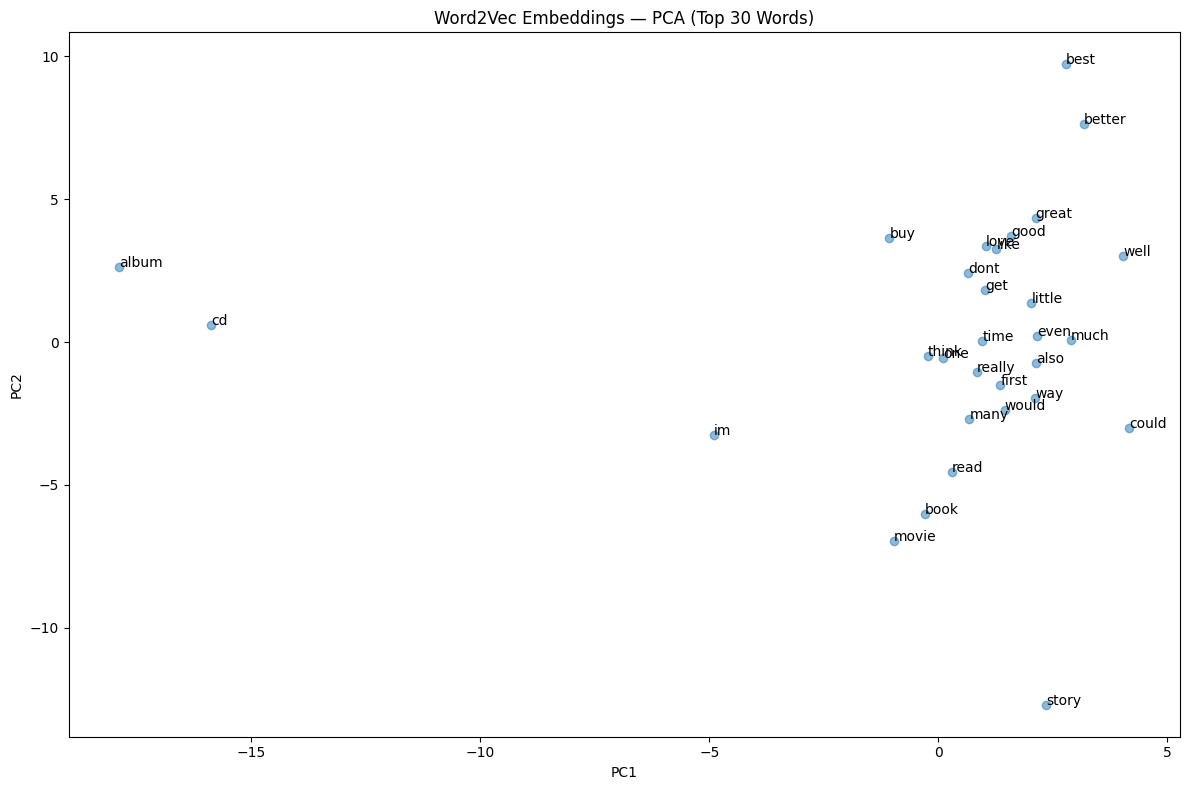

In [10]:
# Visualize embeddings with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Pick top 30 most frequent words
top_words = [w for w, _ in Counter(all_tokens).most_common(30) if w in model.wv]
vectors   = np.array([model.wv[w] for w in top_words])

pca    = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.5)
for i, word in enumerate(top_words):
    plt.annotate(word, coords[i], fontsize=10)
plt.title("Word2Vec Embeddings — PCA (Top 30 Words)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

---
# 🟠 PART 4 — Language Models

---
## ✅ Task 8 — N-gram Language Model

In [11]:
from collections import defaultdict

# Flatten all tokens (with stopwords, for natural language)
all_tokens_lm = [token for tokens in df['tokens'] for token in tokens]

# ---- UNIGRAM MODEL ----
unigram_counts = Counter(all_tokens_lm)
total_unigrams = sum(unigram_counts.values())
unigram_probs  = {w: c / total_unigrams for w, c in unigram_counts.items()}

# ---- BIGRAM MODEL ----
bigram_counts   = Counter(zip(all_tokens_lm, all_tokens_lm[1:]))
bigram_probs    = defaultdict(dict)

for (w1, w2), count in bigram_counts.items():
    bigram_probs[w1][w2] = count / unigram_counts[w1]

def predict_next_unigram(topn=5):
    """Unigram: just the most frequent words, regardless of context."""
    return sorted(unigram_probs.items(), key=lambda x: -x[1])[:topn]

def predict_next_bigram(word, topn=5):
    """Bigram: predict next word given the current word."""
    if word not in bigram_probs:
        return []
    return sorted(bigram_probs[word].items(), key=lambda x: -x[1])[:topn]

# Demo
print("=" * 55)
print("UNIGRAM predictions (no context) — top 5 words:")
for w, p in predict_next_unigram(5):
    print(f"  P('{w}') = {p:.4f}")

print("\nBIGRAM predictions after 'great' — top 5 words:")
for w, p in predict_next_bigram('great', 5):
    print(f"  P('{w}' | 'great') = {p:.4f}")

print("\nBIGRAM predictions after 'sound' — top 5 words:")
for w, p in predict_next_bigram('sound', 5):
    print(f"  P('{w}' | 'sound') = {p:.4f}")

print("""
📌 REFLECTION — Why N-gram models fail on long sentences:
  1. SPARSITY: Most long N-gram sequences never appear in training data.
  2. NO LONG-RANGE DEPS: N-gram window is small (2-3 words max).
     Cannot capture: "The cat that sat on the mat was ___" (needs to remember 'cat').
  3. EXPONENTIAL VOCABULARY: Trigram table has V³ entries — enormous.
  → Transformers solve this with attention over the full sequence.
""")

UNIGRAM predictions (no context) — top 5 words:
  P('the') = 0.0515
  P('and') = 0.0283
  P('i') = 0.0267
  P('a') = 0.0256
  P('to') = 0.0250

BIGRAM predictions after 'great' — top 5 words:
  P('book' | 'great') = 0.0384
  P('and' | 'great') = 0.0384
  P('for' | 'great') = 0.0309
  P('i' | 'great') = 0.0257
  P('but' | 'great') = 0.0234

BIGRAM predictions after 'sound' — top 5 words:
  P('quality' | 'sound') = 0.1022
  P('is' | 'sound') = 0.0795
  P('like' | 'sound') = 0.0658
  P('and' | 'sound') = 0.0602
  P('the' | 'sound') = 0.0409

📌 REFLECTION — Why N-gram models fail on long sentences:
  1. SPARSITY: Most long N-gram sequences never appear in training data.
  2. NO LONG-RANGE DEPS: N-gram window is small (2-3 words max).
     Cannot capture: "The cat that sat on the mat was ___" (needs to remember 'cat').
  3. EXPONENTIAL VOCABULARY: Trigram table has V³ entries — enormous.
  → Transformers solve this with attention over the full sequence.



## ✅ Task 9 — Mini LLM Conceptual Design

In [12]:
print("""
╔══════════════════════════════════════════════════════════╗
║          MINI LLM PIPELINE — Conceptual Design           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  INPUT TEXT: "The guitar sounds amazing"                 ║
║       │                                                  ║
║  ┌────▼────────────────────────────────┐                 ║
║  │  1. TOKENIZATION                    │                 ║
║  │  BPE / WordPiece tokenizer          │                 ║
║  │  → ["The","guitar","sounds","##ing"]│                 ║
║  │  + Special tokens: [CLS], [SEP]     │                 ║
║  └────────────────────┬────────────────┘                 ║
║                       │ token IDs                        ║
║  ┌────────────────────▼────────────────┐                 ║
║  │  2. EMBEDDING LAYER                 │                 ║
║  │  Token Embedding (vocab × d_model)  │                 ║
║  │  + Positional Encoding (sin/cos)    │                 ║
║  │  → Dense vectors [seq_len × 512]    │                 ║
║  └────────────────────┬────────────────┘                 ║
║                       │                                  ║
║  ┌────────────────────▼────────────────┐                 ║
║  │  3. SEQUENCE MODELING               │                 ║
║  │  Transformer Decoder Blocks (×N)    │                 ║
║  │  ├─ Multi-Head Self-Attention       │                 ║
║  │  │  (each token attends to all prev)│                 ║
║  │  ├─ Feed-Forward Network            │                 ║
║  │  └─ Layer Norm + Residual           │                 ║
║  └────────────────────┬────────────────┘                 ║
║                       │                                  ║
║  ┌────────────────────▼────────────────┐                 ║
║  │  4. OUTPUT PREDICTION               │                 ║
║  │  Linear layer: d_model → vocab_size │                 ║
║  │  Softmax → probability over vocab   │                 ║
║  │  Greedy / Beam Search / Sampling    │                 ║
║  └────────────────────┬────────────────┘                 ║
║                       │                                  ║
║  OUTPUT: predicted next token                            ║
╚══════════════════════════════════════════════════════════╝

Key differences from N-gram models:
  • Attention allows any-range dependencies
  • Parameters shared — generalizes to unseen sequences
  • Trained on massive corpora with next-token prediction
""")


╔══════════════════════════════════════════════════════════╗
║          MINI LLM PIPELINE — Conceptual Design           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  INPUT TEXT: "The guitar sounds amazing"                 ║
║       │                                                  ║
║  ┌────▼────────────────────────────────┐                 ║
║  │  1. TOKENIZATION                    │                 ║
║  │  BPE / WordPiece tokenizer          │                 ║
║  │  → ["The","guitar","sounds","##ing"]│                 ║
║  │  + Special tokens: [CLS], [SEP]     │                 ║
║  └────────────────────┬────────────────┘                 ║
║                       │ token IDs                        ║
║  ┌────────────────────▼────────────────┐                 ║
║  │  2. EMBEDDING LAYER                 │                 ║
║  │  Token Embedding (vocab × d_model)  │                 ║
║  │  + Positional Enco

---
# 🔴 PART 5 — Generative AI & LLMs

---
## ✅ Task 10 — Explore LLM Capabilities

> We use `distilgpt2` (a small open-source GPT-2 variant) so this runs **free on Colab CPU** with no API key needed.

In [14]:
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()   # hide noisy load warnings

from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
import time

print("Loading distilgpt2 (open-source LLM)...")
generator = pipeline('text-generation', model='distilgpt2')
print("✅ Text generation model loaded!")

# Summarizer — load explicitly instead of using the pipeline task shortcut
from transformers import BartForConditionalGeneration, BartTokenizer
sum_tokenizer = BartTokenizer.from_pretrained("sshleifer/distilbart-cnn-6-6")
sum_model     = BartForConditionalGeneration.from_pretrained("sshleifer/distilbart-cnn-6-6")
print("✅ Summarization model loaded!")

import torch
from transformers import AutoModelForQuestionAnswering

qa_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased-distilled-squad")
qa_net = AutoModelForQuestionAnswering.from_pretrained("distilbert-base-cased-distilled-squad")

def qa_model(question, context, max_answer_len=30):
    """Return {'answer', 'score'} like the old pipeline: the most likely span in the context."""
    enc = qa_tokenizer(question, context, return_tensors='pt', truncation='only_second',
                       max_length=384, return_offsets_mapping=True)
    offsets = enc.pop('offset_mapping')[0]
    seq_ids = enc.sequence_ids(0)
    with torch.no_grad():
        out = qa_net(**enc)
    start_p = out.start_logits[0].softmax(-1)
    end_p = out.end_logits[0].softmax(-1)
    best, best_score = (0, 0), 0.0
    ctx = [i for i, s in enumerate(seq_ids) if s == 1]          # context tokens only
    for s in ctx:
        for e in ctx:
            if s <= e < s + max_answer_len:
                score = (start_p[s] * end_p[e]).item()
                if score > best_score:
                    best, best_score = (s, e), score
    start_char, end_char = offsets[best[0]][0].item(), offsets[best[1]][1].item()
    return {'answer': context[start_char:end_char], 'score': best_score}

print("✅ QA model loaded!")

# ---- Text Generation ----
print("\n" + "=" * 55)
print("📝 TEXT GENERATION")
prompt = "This guitar has an amazing sound and"
t0 = time.time()
gen_out = generator(prompt, max_new_tokens=60, num_return_sequences=1,
                    do_sample=True, temperature=0.7)
gen_time = time.time() - t0
print(f"Prompt   : '{prompt}'")
print(f"Generated: {gen_out[0]['generated_text']}")
print(f"Time     : {gen_time:.2f}s")

# ---- Summarization ----
print("\n" + "=" * 55)
print("📋 SUMMARIZATION")
long_review = df['text'].iloc[0]
if len(long_review.split()) > 30:
    inputs = sum_tokenizer(long_review[:1024], return_tensors="pt",
                           truncation=True, max_length=512)
    t0 = time.time()
    summary_ids = sum_model.generate(inputs["input_ids"],
                                     max_length=60, min_length=20,
                                     length_penalty=2.0, num_beams=4,
                                     early_stopping=True)
    sum_time = time.time() - t0
    summary_text = sum_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    print(f"Original ({len(long_review.split())} words): {long_review[:200]}...")
    print(f"Summary  : {summary_text}")
    print(f"Time     : {sum_time:.2f}s")
else:
    print("Review too short for summarization, skipping.")

# ---- Question Answering ----
print("\n" + "=" * 55)
print("❓ QUESTION ANSWERING")
context  = df['text'].iloc[1][:500]
question = "What does the reviewer like about the product?"
t0 = time.time()
qa_out = qa_model(question=question, context=context)
qa_time = time.time() - t0
print(f"Context : {context[:150]}...")
print(f"Question: {question}")
print(f"Answer  : {qa_out['answer']}  (score: {qa_out['score']:.4f})")
print(f"Time    : {qa_time:.2f}s")

Loading distilgpt2 (open-source LLM)...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

✅ Text generation model loaded!


Loading weights:   0%|          | 0/262 [00:00<?, ?it/s]

✅ Summarization model loaded!


...

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

✅ QA model loaded!

📝 TEXT GENERATION
Prompt   : 'This guitar has an amazing sound and'
Generated: This guitar has an amazing sound and a tremendous amount of influence. The guitar sounds great and the instrument is sound great.

The guitar is very powerful and the balance is great.
The guitar is just a little too much and the guitar is too much for me to get a feel for the guitar.
The guitar is so
Time     : 2.18s

📋 SUMMARIZATION
Original (75 words): This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I...
Summary  : This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras . It would impress anyone who
Time     : 11.67s

❓ QUESTION ANSWERING
Context : I'm reading a lot of 

In [15]:
print("""
╔═══════════════════════════════════════════════════════════════════╗
║       LLM Comparison: Open-Source vs Closed-Source               ║
╠════════════════╦══════════════════════╦════════════════════════════╣
║ Property       ║ Open-Source          ║ Closed-Source             ║
║                ║ (distilgpt2 / LLaMA) ║ (GPT-4o / Claude)         ║
╠════════════════╬══════════════════════╬════════════════════════════╣
║ Quality        ║ Limited / moderate   ║ High / state-of-art       ║
║ Speed          ║ Fast (local)         ║ Depends on API latency    ║
║ Cost           ║ Free (compute only)  ║ Pay per token             ║
║ Control        ║ Full (weights, tune) ║ Limited (prompt only)     ║
║ Privacy        ║ 100% local           ║ Data sent to vendor       ║
║ Setup          ║ Complex              ║ Easy (API key)            ║
╚════════════════╩══════════════════════╩════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════╗
║       LLM Comparison: Open-Source vs Closed-Source               ║
╠════════════════╦══════════════════════╦════════════════════════════╣
║ Property       ║ Open-Source          ║ Closed-Source             ║
║                ║ (distilgpt2 / LLaMA) ║ (GPT-4o / Claude)         ║
╠════════════════╬══════════════════════╬════════════════════════════╣
║ Quality        ║ Limited / moderate   ║ High / state-of-art       ║
║ Speed          ║ Fast (local)         ║ Depends on API latency    ║
║ Cost           ║ Free (compute only)  ║ Pay per token             ║
║ Control        ║ Full (weights, tune) ║ Limited (prompt only)     ║
║ Privacy        ║ 100% local           ║ Data sent to vendor       ║
║ Setup          ║ Complex              ║ Easy (API key)            ║
╚════════════════╩══════════════════════╩════════════════════════════╝



## ✅ Task 11 — Prompt Engineering

In [16]:
print("""
╔═══════════════════════════════════════════════════════════╗
║              PROMPT ENGINEERING EXAMPLES                  ║
╚═══════════════════════════════════════════════════════════╝

1. SUMMARIZATION PROMPT
────────────────────────
System: You are a review summarizer. Be concise and neutral.

User: Summarize the following customer review in 1-2 sentences,
      focusing on the product's main pros and cons.

Review: \"\"\"{review_text}\"\"\"

Summary:

────────────────────────────────────────────────────────────

2. CLASSIFICATION PROMPT
────────────────────────
System: You are a sentiment classifier. Output ONLY one word.

User: Classify the sentiment of this review as POSITIVE,
      NEGATIVE, or NEUTRAL.

Review: \"\"\"{review_text}\"\"\"

Sentiment:

────────────────────────────────────────────────────────────

3. CREATIVE WRITING PROMPT
────────────────────────────
System: You are a creative copywriter for a music store.

User: Write a catchy 2-sentence product description for a
      guitar based on these customer highlights:
      - Great sound quality
      - Easy to tune
      - Affordable price

Description:

────────────────────────────────────────────────────────────

🔑 KEY PROMPT ENGINEERING TECHNIQUES USED:
  ✅ Role assignment ("You are a...")
  ✅ Output format constraints ("Output ONLY one word")
  ✅ Few-shot / structured input (bullet points)
  ✅ Clear task framing ("Summarize", "Classify")
  ✅ Delimiters for input (triple quotes)
""")


╔═══════════════════════════════════════════════════════════╗
║              PROMPT ENGINEERING EXAMPLES                  ║
╚═══════════════════════════════════════════════════════════╝

1. SUMMARIZATION PROMPT
────────────────────────
System: You are a review summarizer. Be concise and neutral.

User: Summarize the following customer review in 1-2 sentences,
      focusing on the product's main pros and cons.

Review: """{review_text}"""

Summary:

────────────────────────────────────────────────────────────

2. CLASSIFICATION PROMPT
────────────────────────
System: You are a sentiment classifier. Output ONLY one word.

User: Classify the sentiment of this review as POSITIVE,
      NEGATIVE, or NEUTRAL.

Review: """{review_text}"""

Sentiment:

────────────────────────────────────────────────────────────

3. CREATIVE WRITING PROMPT
────────────────────────────
System: You are a creative copywriter for a music store.

User: Write a catchy 2-sentence product description for a
      gui

---
# 🟣 PART 6 — Classification

---
## ✅ Task 12 — Two Classifiers: Discriminative vs Generative

We classify reviews as **Positive** vs **Negative** using the dataset's own labels (mapped earlier to 5★ / 1★).

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# Binary labels from the dataset: 1 = Positive (5★), 0 = Negative (1★)
df_clf = df.copy()
df_clf['label'] = (df_clf['rating'] >= 4).astype(int)

print(f"Dataset for classification: {len(df_clf)} samples")
print(f"Positive: {df_clf['label'].sum()}  |  Negative: {(df_clf['label'] == 0).sum()}")

df_clf['clean_no_stop'] = df_clf['tokens_no_stop'].apply(lambda t: ' '.join(t))
X = df_clf['clean_no_stop']
y = df_clf['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results = {}

# ---- Approach A: Discriminative ----
print("\n" + "=" * 55)
print("APPROACH A — Discriminative (Logistic Regression + TF-IDF)")
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LogisticRegression(max_iter=500))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
results['Logistic Regression'] = acc_lr
print(f"Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Positive']))

print("\nApproach A — Discriminative (SVM + TF-IDF)")
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LinearSVC(max_iter=1000))
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
results['SVM'] = acc_svm
print(f"Accuracy: {acc_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Negative','Positive']))

# ---- Approach B: Generative ----
print("\n" + "=" * 55)
print("APPROACH B — Generative (Naive Bayes + Count Vectorizer)")
pipe_nb = Pipeline([
    ('cv',  CountVectorizer(max_features=5000)),
    ('clf', MultinomialNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
results['Naive Bayes'] = acc_nb
print(f"Accuracy: {acc_nb:.4f}")
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Positive']))

Dataset for classification: 20000 samples
Positive: 10257  |  Negative: 9743

APPROACH A — Discriminative (Logistic Regression + TF-IDF)
Accuracy: 0.8330
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83      1949
    Positive       0.84      0.83      0.84      2051

    accuracy                           0.83      4000
   macro avg       0.83      0.83      0.83      4000
weighted avg       0.83      0.83      0.83      4000


Approach A — Discriminative (SVM + TF-IDF)
Accuracy: 0.8127
              precision    recall  f1-score   support

    Negative       0.80      0.81      0.81      1949
    Positive       0.82      0.81      0.82      2051

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000


APPROACH B — Generative (Naive Bayes + Count Vectorizer)
Accuracy: 0.8123
              precision    recall  f1-score   support

 

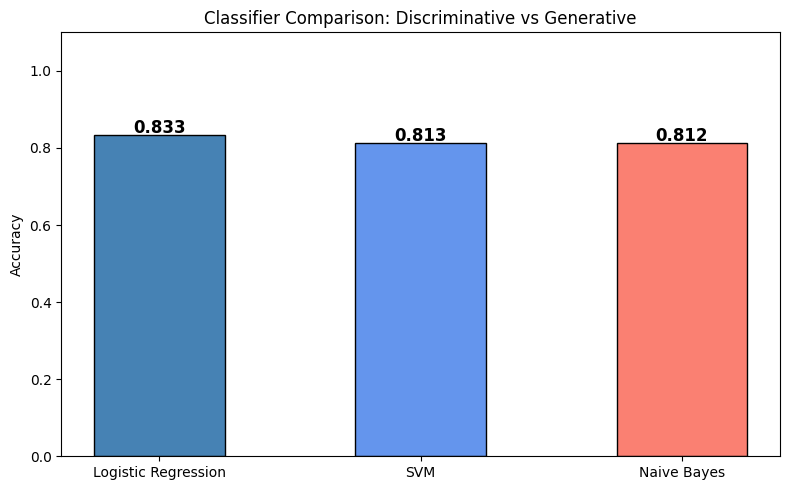


╔═══════════════════════════════════════════════════════════════╗
║        Classifier Comparison Summary                          ║
╠══════════════════╦════════════╦═══════════════╦═══════════════╣
║ Property         ║ Log. Reg.  ║ SVM           ║ Naive Bayes   ║
╠══════════════════╬════════════╬═══════════════╬═══════════════╣
║ Type             ║ Discrim.   ║ Discrim.      ║ Generative    ║
║ Models           ║ P(y|x)     ║ Decision bdry ║ P(x|y)*P(y)   ║
║ Interpretability ║ Medium     ║ Low           ║ High          ║
║ Data needed      ║ Medium     ║ Medium        ║ Low           ║
║ Speed            ║ Fast       ║ Fast          ║ Fastest       ║
║ Best for         ║ General    ║ High dim      ║ Small data    ║
╚══════════════════╩════════════╩═══════════════╩═══════════════╝

📌 Key takeaways:
  - Discriminative models (LR, SVM) usually achieve HIGHER accuracy
    because they directly optimize the decision boundary.
  - Naive Bayes is FASTER and works well with little data,
    

In [18]:
# ---- Visualization: Accuracy Comparison ----
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(),
               color=['steelblue', 'cornflowerblue', 'salmon'],
               edgecolor='black', width=0.5)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Classifier Comparison: Discriminative vs Generative")
plt.tight_layout()
plt.show()

print("""
╔═══════════════════════════════════════════════════════════════╗
║        Classifier Comparison Summary                          ║
╠══════════════════╦════════════╦═══════════════╦═══════════════╣
║ Property         ║ Log. Reg.  ║ SVM           ║ Naive Bayes   ║
╠══════════════════╬════════════╬═══════════════╬═══════════════╣
║ Type             ║ Discrim.   ║ Discrim.      ║ Generative    ║
║ Models           ║ P(y|x)     ║ Decision bdry ║ P(x|y)*P(y)   ║
║ Interpretability ║ Medium     ║ Low           ║ High          ║
║ Data needed      ║ Medium     ║ Medium        ║ Low           ║
║ Speed            ║ Fast       ║ Fast          ║ Fastest       ║
║ Best for         ║ General    ║ High dim      ║ Small data    ║
╚══════════════════╩════════════╩═══════════════╩═══════════════╝

📌 Key takeaways:
  - Discriminative models (LR, SVM) usually achieve HIGHER accuracy
    because they directly optimize the decision boundary.
  - Naive Bayes is FASTER and works well with little data,
    making it great for baselines and low-resource settings.
  - For production sentiment analysis, Logistic Regression with
    TF-IDF is a strong, interpretable baseline.
""")

### 🔬 Experiment: does removing stopwords hurt sentiment?

Task 2 warned that NLTK's stopword list removes **"not"**, **"no"** and **"nor"**, which can flip meaning (*"not good"* → *"good"*). The classifiers above used that list. Here we test it directly: the same Logistic Regression + TF-IDF model (with bigrams, so phrases like *"not good"* become features), trained on three versions of the text.

Standard stopwords removed   accuracy: 0.8435
Negations kept               accuracy: 0.8548
No stopword removal          accuracy: 0.8578


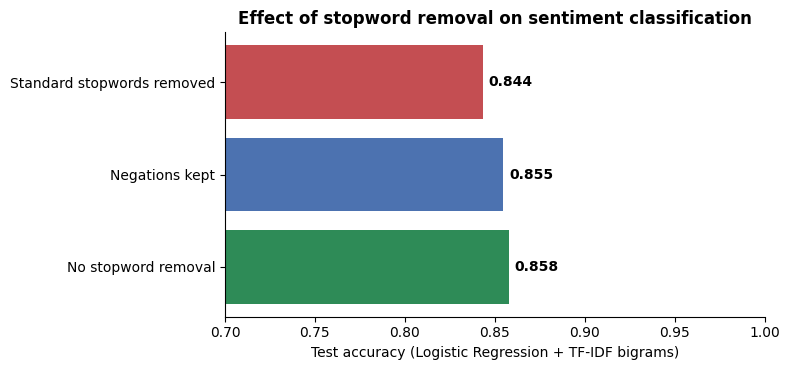

In [19]:
variants = {
    'Standard stopwords removed':  df_clf['tokens_no_stop'],
    'Negations kept':               df.loc[df_clf.index, 'tokens_keep_neg'],
    'No stopword removal':          df.loc[df_clf.index, 'tokens'],
}
neg_results = {}
for name, toks in variants.items():
    text = toks.apply(lambda t: ' '.join(t))
    Xtr, Xte, ytr, yte = train_test_split(text, y, test_size=0.2, random_state=42, stratify=y)
    pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
                     ('clf', LogisticRegression(max_iter=1000))])
    pipe.fit(Xtr, ytr)
    neg_results[name] = accuracy_score(yte, pipe.predict(Xte))
    print(f"{name:<28} accuracy: {neg_results[name]:.4f}")

plt.figure(figsize=(8, 3.8))
bars = plt.barh(list(neg_results)[::-1], list(neg_results.values())[::-1], color=['#2E8B57', '#4C72B0', '#C44E52'])
plt.bar_label(bars, fmt='%.3f', padding=4, fontweight='bold')
plt.xlim(0.7, 1.0)
plt.xlabel('Test accuracy (Logistic Regression + TF-IDF bigrams)')
plt.title('Effect of stopword removal on sentiment classification', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
# 🎉 Project Complete!

| Part | Tasks | Status |
|------|-------|--------|
| Part 1: Text Processing | Tasks 1, 2, 3 | ✅ Done |
| Part 2: Text Representation | Tasks 4, 5 | ✅ Done |
| Part 3: Word Embeddings | Tasks 6, 7 | ✅ Done |
| Part 4: Language Models | Tasks 8, 9 | ✅ Done |
| Part 5: Generative AI & LLMs | Tasks 10, 11 | ✅ Done |
| Part 6: Classification | Task 12 | ✅ Done |